In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("orders.csv") # dane do 28.08.2018
df = df[df['order_status'] == 'delivered'] 

In [104]:
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])
daily = df.groupby(df['order_purchase_timestamp'].dt.date).size().reset_index(name='y')

In [105]:
daily = daily.rename(columns={
    'order_purchase_timestamp': 'ds'
})
daily['ds'] = pd.to_datetime(daily['ds'])


In [106]:
print(daily.head())

          ds   y
0 2016-09-15   1
1 2016-10-03   7
2 2016-10-04  54
3 2016-10-05  35
4 2016-10-06  41


In [107]:
import plotly
print(plotly.__version__)

6.6.0


In [108]:
from prophet import Prophet

In [109]:
model = Prophet()
model.fit(daily)

23:50:24 - cmdstanpy - INFO - Chain [1] start processing
23:50:24 - cmdstanpy - INFO - Chain [1] done processing


In [110]:
future = model.make_future_dataframe(periods=30)

In [111]:
forecast = model.predict(future)

In [112]:
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']]

,ds,yhat,yhat_lower,yhat_upper
0,2016-09-15,-5.440190,-77.248435,68.697458
1,2016-10-03,17.308691,-58.501113,90.867540
2,2016-10-04,15.453010,-61.144539,95.952046
3,2016-10-05,10.731444,-66.451309,87.149565
4,2016-10-06,4.216266,-74.558170,79.828483
...,...,...,...,...
637,2018-09-24,221.567698,145.837402,296.882056
638,2018-09-25,219.111143,138.953457,297.177679
639,2018-09-26,213.788705,140.922098,295.485289
640,2018-09-27,206.672653,126.132784,287.741380


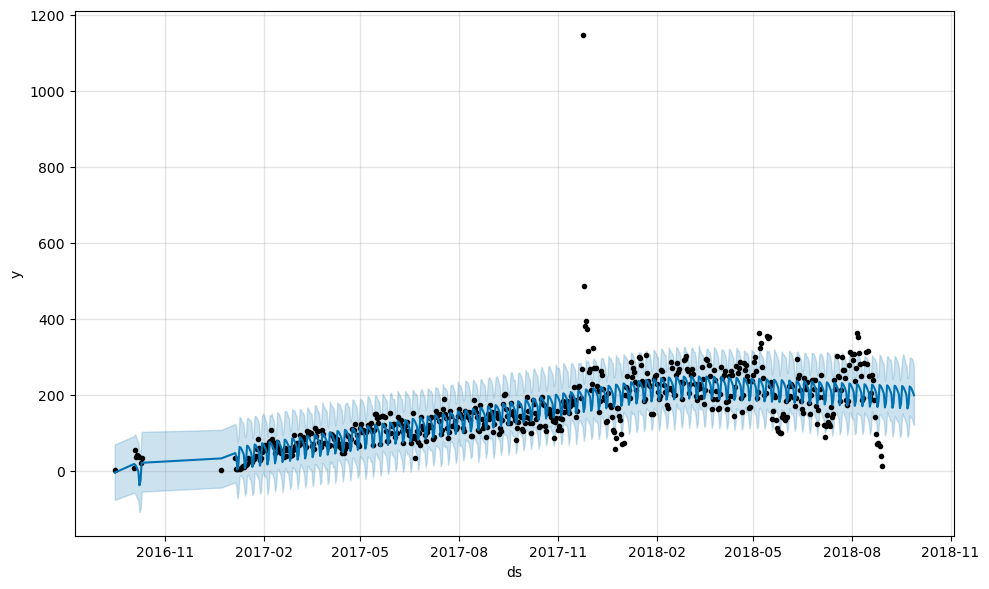

In [113]:
import matplotlib.pyplot as plt
fig = model.plot(forecast) #historia + prognoza 30 dni (do 28.09.2018)
plt.show() # czarne punkty - dane historyczne, niebieska linia - prognoza (yhat), jasnoniebieski obszar - niepewnosc (yhat_lower, yhat_upper)

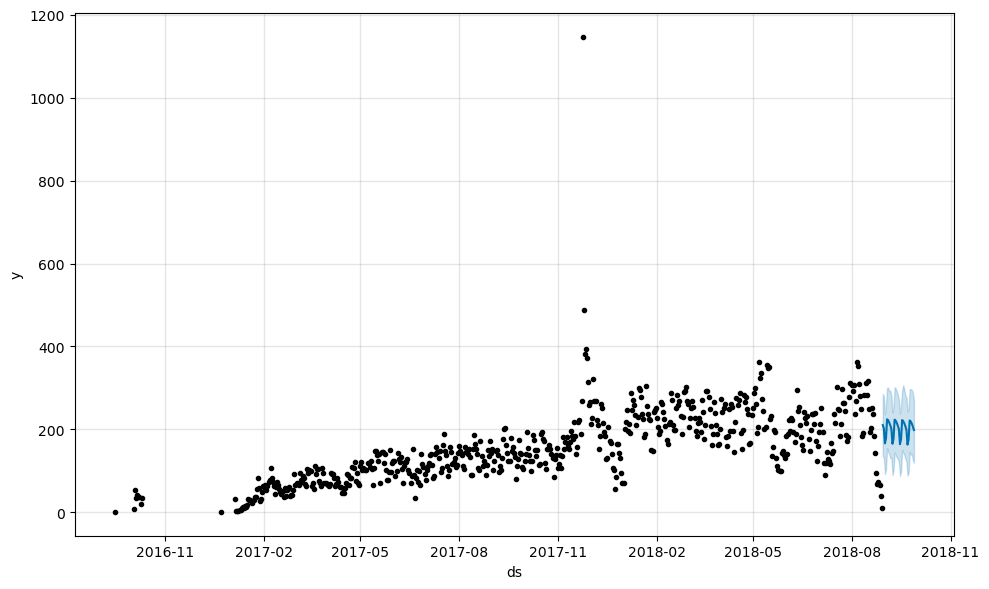

In [114]:
future_only = forecast[forecast['ds'] > daily['ds'].max()] # filtr przyszlosci
fig2 = model.plot(future_only) #tylko prognoza 30 dni
plt.show()

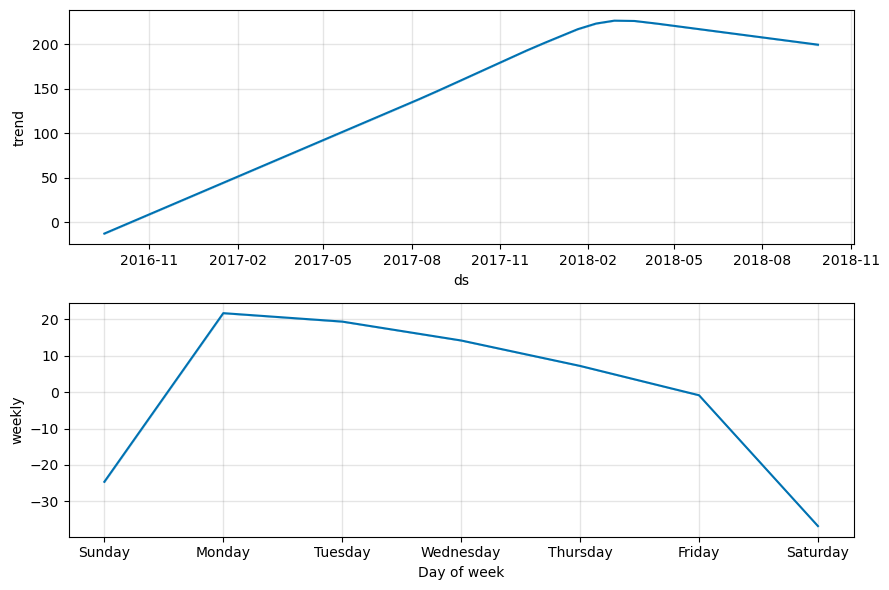

In [115]:
fig3 = model.plot_components(forecast) #trend roczny (dlugoterminowy) i tygodniowy (peak - poniedzialek i wtorek)
plt.show()

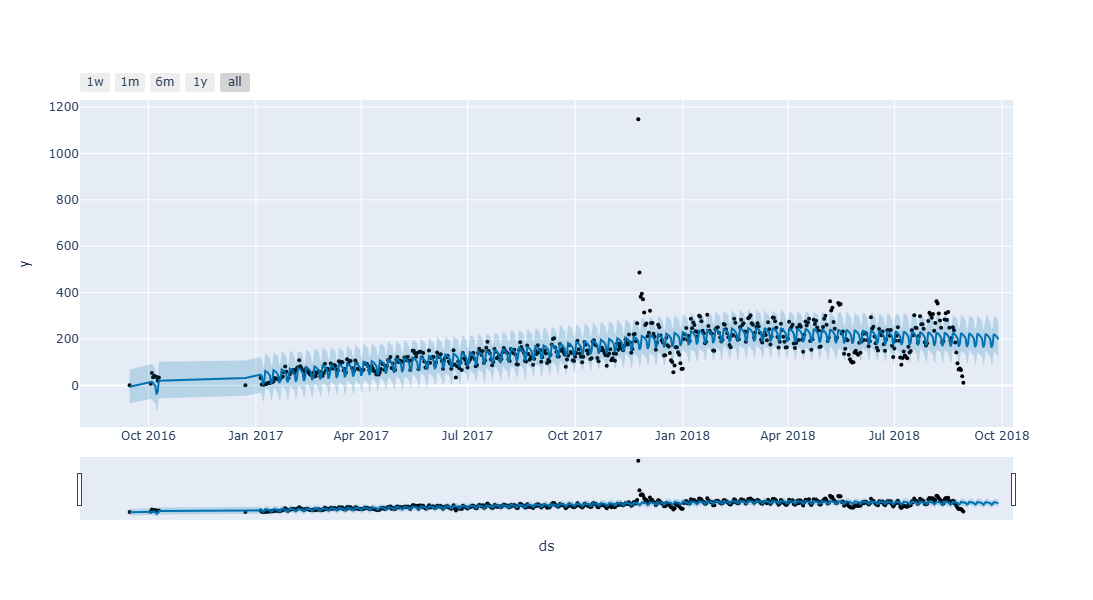

In [116]:
from prophet.plot import plot_plotly
fig4 = plot_plotly(model, forecast) # wersja interaktywna prognozy
fig4.show()

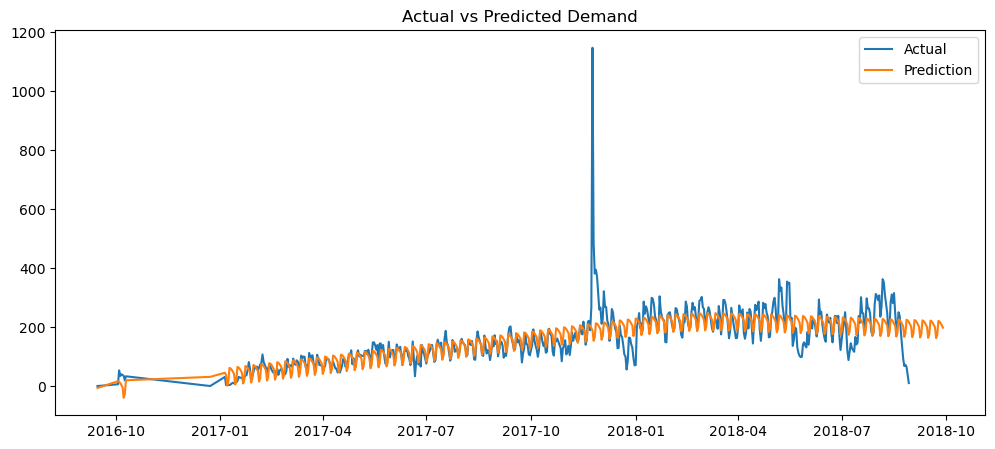

In [117]:
import matplotlib.pyplot as plt
# porownanie realne vs przewidywane przez model, gdzie model sie myli, czy jest zgodny z trendami, czy wyplaszcza dane
plt.figure(figsize=(12,5)) 
plt.plot(daily['ds'], daily['y'], label="Actual") #dane historyczne
plt.plot(forecast['ds'], forecast['yhat'], label="Prediction") # dane przewidywane
plt.legend()
plt.title("Actual vs Predicted Demand")
plt.show()

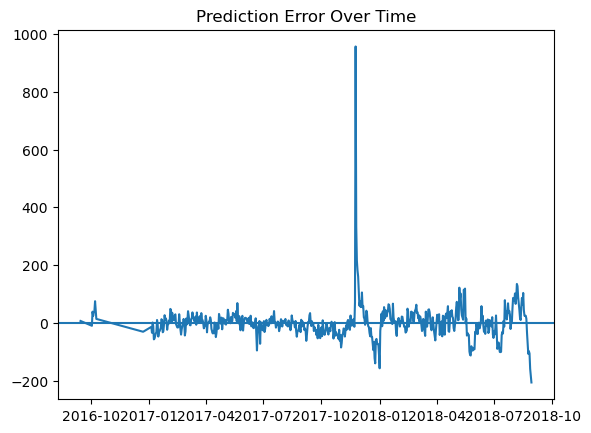

In [118]:
df = forecast.merge(daily, on="ds")
df['error'] = df['y'] - df['yhat']
plt.figure()
plt.plot(df['ds'], df['error']) # blad modelu w stosunku do rzeczywistych danych (na plusie - model niedoszacowal, na minusie - model przeszacowal)
plt.title("Prediction Error Over Time")
plt.axhline(0)
plt.show()

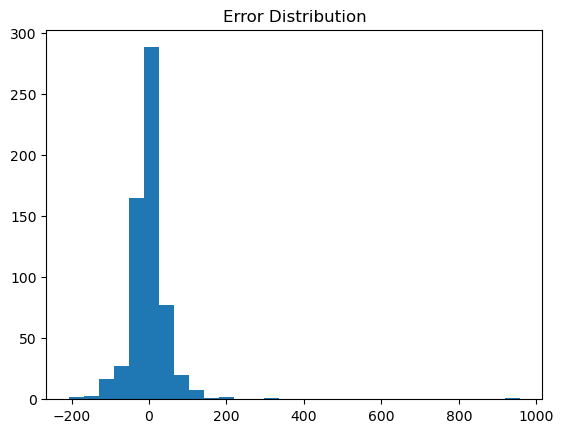

In [119]:
plt.hist(df['error'], bins=30) # histogram bledow, są skupione wokol 0, co wskazuje na dobry model), widzimy tendecje do niedoszacowania
plt.title("Error Distribution")
plt.show()

In [120]:
#porownanie sredniej rzeczywistej i prognozowanej
print("Mean actual:", daily['y'].mean()) 
print("Mean forecast:", forecast['yhat'].mean())

Mean actual: 157.6437908496732
Mean forecast: 159.7180081310302


In [121]:
#odchylenie standardowe bledow,wszystko co > 2σ = anomalia
df['anomaly'] = abs(df['error']) > df['error'].std() * 2
df[df['anomaly']]
#24 listopada 2017 to black friday, taka ciekawostka

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat,y,error,anomaly
333,2017-11-24,190.605075,115.193917,262.567630,190.605075,190.605075,-0.878098,-0.878098,-0.878098,-0.878098,-0.878098,-0.878098,0.0,0.0,0.0,189.726977,1147,957.273023,True
334,2017-11-25,191.072039,78.056743,228.790916,191.072039,191.072039,-36.760618,-36.760618,-36.760618,-36.760618,-36.760618,-36.760618,0.0,0.0,0.0,154.311421,487,332.688579,True
335,2017-11-26,191.539002,94.515022,242.904769,191.539002,191.539002,-24.622896,-24.622896,-24.622896,-24.622896,-24.622896,-24.622896,0.0,0.0,0.0,166.916106,382,215.083894,True
336,2017-11-27,192.005966,137.923307,290.800736,192.005966,192.005966,21.636488,21.636488,21.636488,21.636488,21.636488,21.636488,0.0,0.0,0.0,213.642454,395,181.357546,True
337,2017-11-28,192.472929,135.182833,286.573326,192.472929,192.472929,19.320976,19.320976,19.320976,19.320976,19.320976,19.320976,0.0,0.0,0.0,211.793905,372,160.206095,True
363,2017-12-24,204.379095,102.198239,254.090408,204.379095,204.379095,-24.622896,-24.622896,-24.622896,-24.622896,-24.622896,-24.622896,0.0,0.0,0.0,179.756198,57,-122.756198,True
364,2017-12-25,204.826485,154.753152,304.728566,204.826485,204.826485,21.636488,21.636488,21.636488,21.636488,21.636488,21.636488,0.0,0.0,0.0,226.462973,86,-140.462973,True
371,2018-01-01,207.958212,154.561533,306.650792,207.958212,207.958212,21.636488,21.636488,21.636488,21.636488,21.636488,21.636488,0.0,0.0,0.0,229.594701,72,-157.594701,True
497,2018-05-07,219.677053,164.342755,317.846587,219.677053,219.677053,21.636488,21.636488,21.636488,21.636488,21.636488,21.636488,0.0,0.0,0.0,241.313542,363,121.686458,True
588,2018-08-06,206.842255,151.245031,300.609677,206.842255,206.842255,21.636488,21.636488,21.636488,21.636488,21.636488,21.636488,0.0,0.0,0.0,228.478743,363,134.521257,True


In [138]:
df_raw = daily.copy()
df_raw['month'] = df_raw['ds'].dt.month
#podzial miesiecy na dwie grupy
holiday_months = df_raw[df_raw['month'].isin([11, 12])]  # black friday i swieta
normal_months = df_raw[~df_raw['month'].isin([11, 12])]
#srednia dwoch grup, listopad+grudzien duzo wyzsza niz reszta - 35%
holiday_mean = holiday_months['y'].mean()
normal_mean = normal_months['y'].mean()
print("Holiday mean:", holiday_mean)
print("Normal mean:", normal_mean)
uplift = (holiday_mean - normal_mean) / normal_mean * 100
print("Holiday uplift %:", uplift)

Holiday mean: 206.5
Normal mean: 152.13636363636363
Holiday uplift %: 35.733492680011956


C:\Users\darlo\AppData\Local\Temp\ipykernel_12532\283598043.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered['day'] = df_filtered['ds'].dt.day


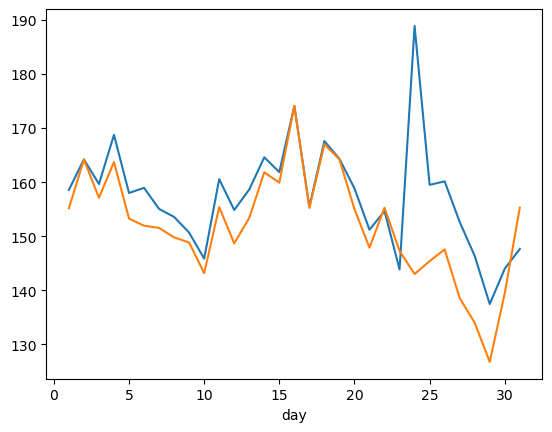

In [129]:
#sprzedaz wg dni miesiaca, jeden black friday znieksztalca caly wykres
#na zolto wykres bez uwzglednienia listopada i grudnia
df['day'] = df['ds'].dt.day
df.groupby('day')['y'].mean().plot()
df_filtered = df[~df['ds'].dt.month.isin([11, 12])]
df_filtered['day'] = df_filtered['ds'].dt.day
df_filtered.groupby('day')['y'].mean().plot()
df = forecast.merge(daily, on="ds", how="inner")

<Axes: xlabel='month'>

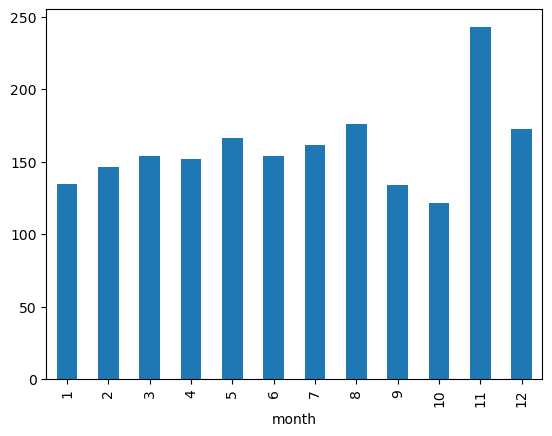

In [124]:
#wykres sezonowosci miesiecznej
df['month'] = df['ds'].dt.month
df.groupby('month')['y'].mean().plot(kind='bar')

<Axes: xlabel='ds'>

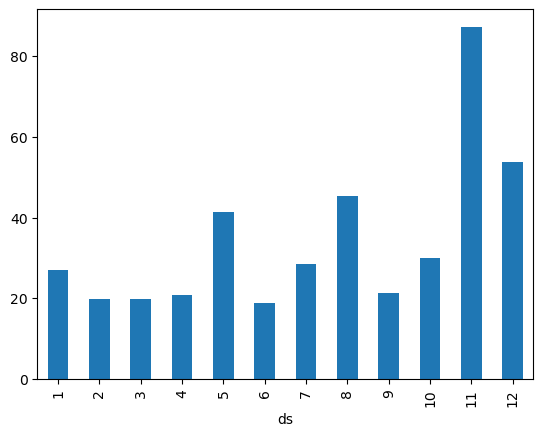

In [130]:
#sredni blad wg miesiaca, listopad i grudzien oczywiscie najwyzej
df['abs_error'] = abs(df['y'] - df['yhat'])
df.groupby(df['ds'].dt.month)['abs_error'].mean().plot(kind='bar')

In [131]:
#ratio najlepszego dnia do sredniej, pokazuje na ile dane sa wrazliwe na eventy
peak = df['y'].max()
avg = df['y'].mean()

print("Peak/Avg ratio:", peak / avg)

Peak/Avg ratio: 7.275897095710939


In [132]:
# wnioski:
#model wykrywa wzorce sezonowe i swietnie radzi sobie z predykcja dlugoterminową, 
# ale nie zna kontekstu eventów więc największe błędy są widoczne w pobliżu konkretnych eventow 
# (najbardziej widoczne przy black friday i swietach bozego narodzenia)


In [133]:
forecast.to_csv("forecast.csv", index=False)